In [1]:
import numpy as np
import torch
from torch import nn
# Generate some data
m = 0.1234
c = 0.6789
X = np.arange(0,2,0.04)
y = m*X + c

split = int(0.8*len(X))
X_train, y_train = X[:split],y[:split]
X_test, y_test = X[split:],y[split:]

X_train_tensors = torch.from_numpy(X_train)
y_train_tensors = torch.from_numpy(y_train)
X_test_tensors = torch.from_numpy(X_test)
y_test_tensors = torch.from_numpy(y_test)
print(f"Shape of X_train is {X_train.shape} and type is {type(X_train)}")
print(f"Shape of X_train_tensor is {X_train_tensors.shape} and type is {type(X_train_tensors)}")


Shape of X_train is (40,) and type is <class 'numpy.ndarray'>
Shape of X_train_tensor is torch.Size([40]) and type is <class 'torch.Tensor'>


In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

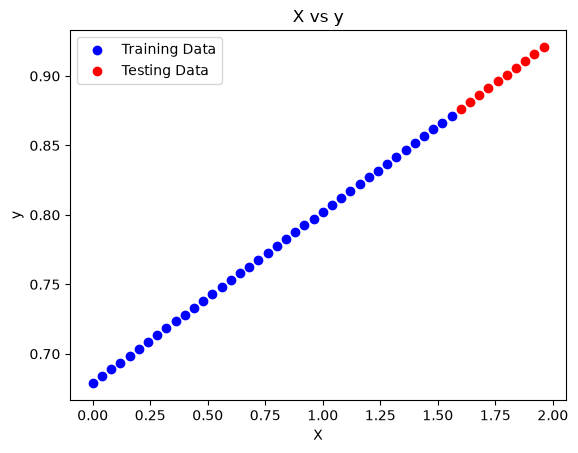

In [3]:
import matplotlib.pyplot as plt
def plot_data(
        X_train = X_train_tensors, y_train=y_train_tensors, X_test=X_test_tensors, y_test=y_test_tensors, predictions=None):
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='r', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('X vs y')
    plt.legend()
    plt.show()

plot_data()

In [4]:
class MyFirstNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,requires_grad=True,
                                             dtype=torch.float))

    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.weights*x + self.bias

In [5]:
torch.manual_seed(42)
model = MyFirstNeuralNetwork()
print(model.state_dict())

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])


In [6]:
# Set up loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(
    params = model.parameters(),
    lr = 0.1
)

In [7]:
# Set up the training loop
epochs = 500
train_loss_list = []
test_loss_list = []

# Move everything to device
model.to(device)
X_train_tensors, y_train_tensors = X_train_tensors.to(device), y_train_tensors.to(device)
X_test_tensors, y_test_tensors = X_test_tensors.to(device), y_test_tensors.to(device)
for epoch in range(epochs):
    ## TRAINING MODE
    model.train()
    # 1. FORWARD PASS
    train_preds = model(X_train_tensors)
    # 2. COMPUTE THE TRAINING LOSS
    train_loss = loss_fn(y_train_tensors, train_preds)
    # 3. ZERO GRAD THE OPTIMIZER
    optimizer.zero_grad()
    # 4. BACKPROPAGATE
    train_loss.backward()
    # 5. UPDATE THE PARAMETERS
    optimizer.step()
    ## TESTING MODE
    model.eval()
    with torch.inference_mode():
        test_preds = model(X_test_tensors)
        test_loss = loss_fn(y_test_tensors, test_preds)
    train_loss_list.append(train_loss.detach().cpu())
    test_loss_list.append(test_loss.detach().cpu())
    if (epoch+1) % 50 ==0:
        print(f'Epoch {epoch} | Train Loss {train_loss:.4f} | Test Loss {test_loss:.4f}')


Epoch 49 | Train Loss 0.0029 | Test Loss 0.0097
Epoch 99 | Train Loss 0.0002 | Test Loss 0.0008
Epoch 149 | Train Loss 0.0000 | Test Loss 0.0001
Epoch 199 | Train Loss 0.0000 | Test Loss 0.0000
Epoch 249 | Train Loss 0.0000 | Test Loss 0.0000
Epoch 299 | Train Loss 0.0000 | Test Loss 0.0000
Epoch 349 | Train Loss 0.0000 | Test Loss 0.0000
Epoch 399 | Train Loss 0.0000 | Test Loss 0.0000
Epoch 449 | Train Loss 0.0000 | Test Loss 0.0000
Epoch 499 | Train Loss 0.0000 | Test Loss 0.0000


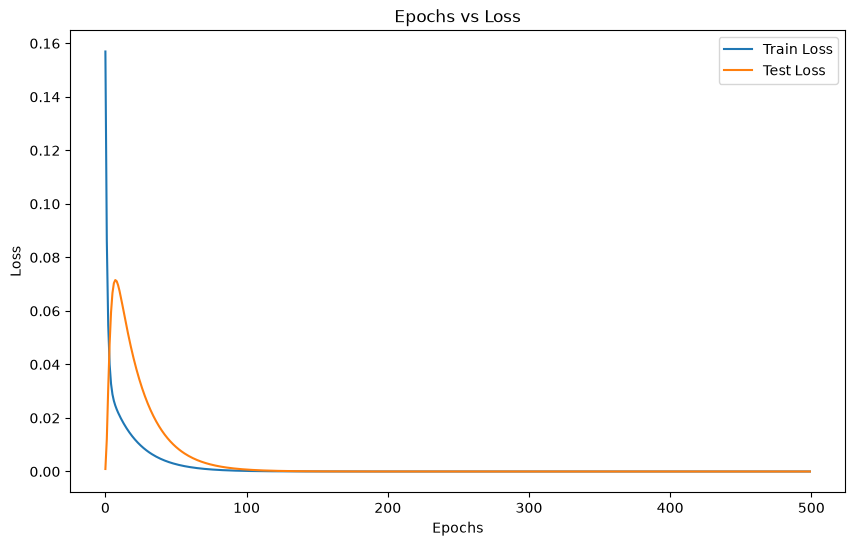

In [8]:
# Plot loss curve
plt.figure(figsize=(10,6))
plt.plot(range(epochs), train_loss_list, label = "Train Loss")
plt.plot(range(epochs), test_loss_list, label = "Test Loss")
plt.title("Epochs vs Loss");
plt.xlabel("Epochs");
plt.ylabel("Loss")
plt.legend();
plt.show()

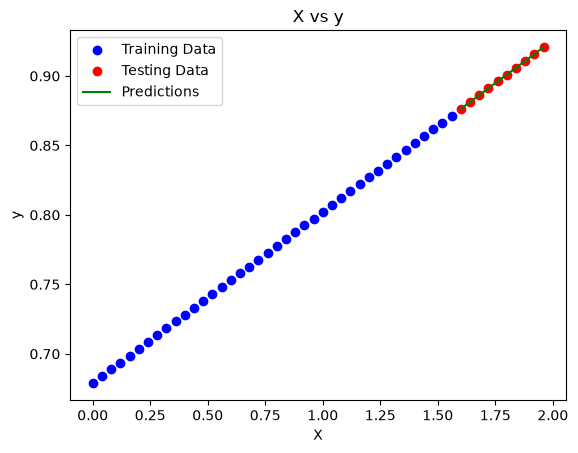

In [9]:
with torch.inference_mode():
    y_preds = model(X_test_tensors)

plot_data(predictions=y_preds.cpu())